# Bangladesh Road Accident Analysis 

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [40]:
df = pd.read_csv("data/road_accidents_bangladesh_cleaned.csv")
df.head()

,id,title,date,article_url,place_of_accident,district,number_of_deaths,number_of_injured,vehicle_type,cause_of_accident,country,report_type,type_of_accident
0,6,"Road accident in Cox’s Bazar leaves 3 dead, 7 ...",2025-06-16 11:43:58,https://en.prothomalo.com/bangladesh/accident/...,chattogram-cox’s bazar highway in ramu upazila,cox’s bazar,3,7,passenger bus and a covered van,head-on collision,Bangladesh,event,road accident
1,8,"Two killed, four injured in Khulna road accident",2025-06-09 12:29:25,https://en.prothomalo.com/bangladesh/accident/...,darogar bhita area near rupsha bridge,khulna,2,4,truck and easy-bike,head-on collision,Bangladesh,event,road accident
2,12,Marma girl's accident injury being propagated ...,2025-01-18 17:15:50,https://en.prothomalo.com/bangladesh/ij8ukl3niq,chattogram,chattogram,0,1,bike,bike accident,Bangladesh,event,road accident
3,15,Four killed in two separate accidents on expre...,2025-01-03 11:19:06,https://en.prothomalo.com/bangladesh/accident/...,nimtala area in sirajdikhan upazila,munshiganj,2,5,bus and covered van,bus rammed into a parked covered van,Bangladesh,event,road accident
4,16,"Cause of accident, whereabouts of driver still...",2024-12-28 14:09:42,https://en.prothomalo.com/bangladesh/local-new...,dhaleshwari toll plaza on dhaka-mawa expressway,NaN,6,0,"bus, cars",NaN,Bangladesh,event,road accident


In [41]:
df.shape

(2985, 13)

In [42]:
df.columns

Index(['id', 'title', 'date', 'article_url', 'place_of_accident', 'district',
       'number_of_deaths', 'number_of_injured', 'vehicle_type',
       'cause_of_accident', 'country', 'report_type', 'type_of_accident'],
      dtype='str')

In [43]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2985 entries, 0 to 2984
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   id                 2985 non-null   int64
 1   title              2985 non-null   str  
 2   date               2985 non-null   str  
 3   article_url        2637 non-null   str  
 4   place_of_accident  2937 non-null   str  
 5   district           2878 non-null   str  
 6   number_of_deaths   2985 non-null   int64
 7   number_of_injured  2985 non-null   int64
 8   vehicle_type       2365 non-null   str  
 9   cause_of_accident  2525 non-null   str  
 10  country            2985 non-null   str  
 11  report_type        2980 non-null   str  
 12  type_of_accident   2985 non-null   str  
dtypes: int64(3), str(10)
memory usage: 303.3 KB


In [44]:
df.isnull().sum()

id                     0
title                  0
date                   0
article_url          348
place_of_accident     48
district             107
number_of_deaths       0
number_of_injured      0
vehicle_type         620
cause_of_accident    460
country                0
report_type            5
type_of_accident       0
dtype: int64

In [45]:
df.describe()

,id,number_of_deaths,number_of_injured
count,2985.000000,2985.000000,2985.000000
mean,2966.335008,10.167504,11.345729
std,1827.436556,91.047649,135.455546
min,6.000000,0.000000,-1.000000
25%,1344.000000,1.000000,0.000000
50%,2926.000000,2.000000,0.000000
75%,4327.000000,3.000000,3.000000
max,6516.000000,1810.000000,2515.000000


In [46]:
df = df.drop_duplicates()
df = df.fillna("Unknown")

In [47]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

In [48]:
df["hour"] = df["date"].dt.hour
df["day"] = df["date"].dt.day_name()

In [49]:
def time_category(hour):
    if hour < 12:
        return "Morning"
    elif hour < 18:
        return "Afternoon"
    else:
        return "Night"

df["time_category"] = df["hour"].apply(time_category)

In [50]:
df[["date", "hour", "day", "time_category"]].head()

,date,hour,day,time_category
0,2025-06-16 11:43:58,11,Monday,Morning
1,2025-06-09 12:29:25,12,Monday,Afternoon
2,2025-01-18 17:15:50,17,Saturday,Afternoon
3,2025-01-03 11:19:06,11,Friday,Morning
4,2024-12-28 14:09:42,14,Saturday,Afternoon


In [51]:
df["hour"].value_counts().sort_index()
df["district"].value_counts().head(10)
df["day"].value_counts()
df["time_category"].value_counts()

time_category
Afternoon    1349
Morning       856
Night         756
Name: count, dtype: int64

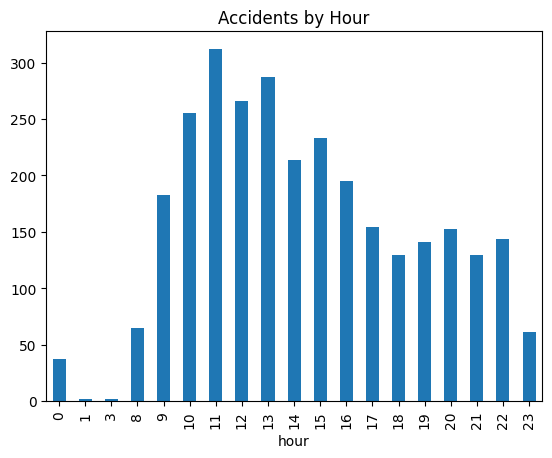

In [52]:
df["hour"].value_counts().sort_index().plot(kind="bar")
plt.title("Accidents by Hour")
plt.show()

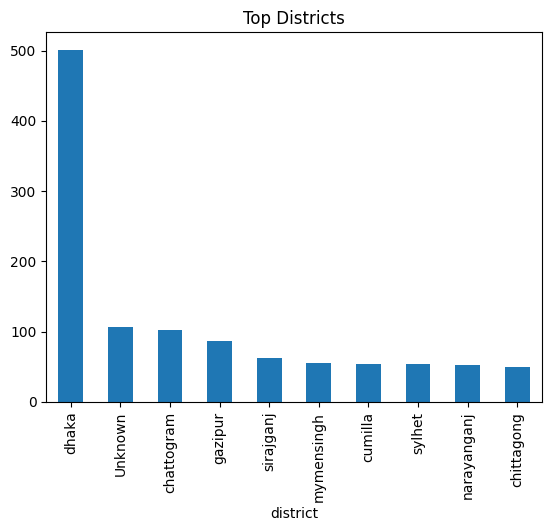

In [53]:
df["district"].value_counts().head(10).plot(kind="bar")
plt.title("Top Districts")
plt.show()

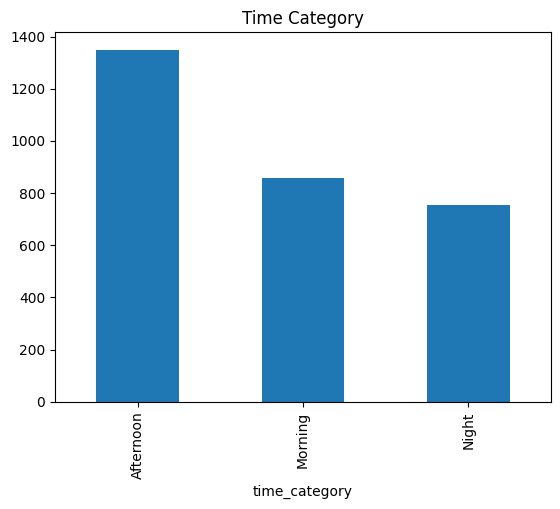

In [54]:
df["time_category"].value_counts().plot(kind="bar")
plt.title("Time Category")
plt.show()

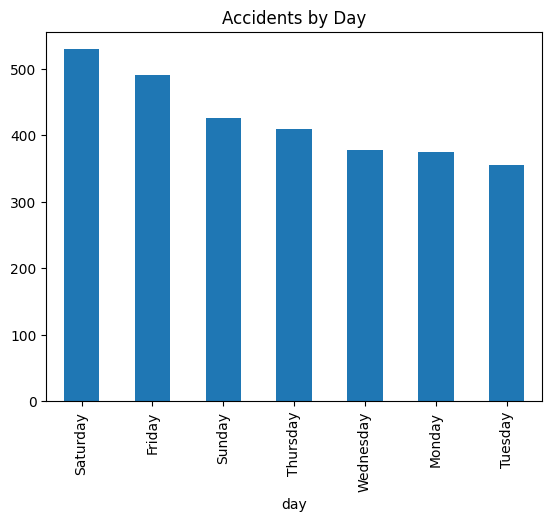

In [55]:
df["day"].value_counts().plot(kind="bar")
plt.title("Accidents by Day")
plt.show()

In [56]:
plt.savefig("charts/hour.png")

<Figure size 640x480 with 0 Axes>